In [57]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import orjson

In [112]:
folder = "./openpose_output_train/json/"
count = len(os.listdir(folder))
print(count)

31047


In [9]:
data["people"][0].keys()

dict_keys(['person_id', 'pose_keypoints_2d', 'face_keypoints_2d', 'hand_left_keypoints_2d', 'hand_right_keypoints_2d', 'pose_keypoints_3d', 'face_keypoints_3d', 'hand_left_keypoints_3d', 'hand_right_keypoints_3d'])

# DATA CLEANING

This code cleans ur data. After u download from the openpose website and expand the file, you should have the file structure:

    /[openpose_output]
      /json
        /[video clip folders]
          /[frame].json
  
Change "ROOT" to the directory "[openpose_output]/json" or whatevery your directory is

The end result should be a dictionary "all_data" with:
- "sentence_id": identification of the sentence
- "pose_keypoints_2d": body features
- "face_keypoints_2d": facial features
- "hand_left_keypoints_2d": left hand features
- "hand_right_keypoints_2d": right hand features

In [60]:
%%time
# ---------- config ----------
ROOT = "openpose_output_val/json"

# ---------- optional: faster json loader ----------
def load_json(path):
    with open(path, "rb") as f:
        return orjson.loads(f.read())

# ---------- collect clip folders ----------
clip_dirs = sorted(
    entry.path
    for entry in os.scandir(ROOT)
    if entry.is_dir()
)

all_data = {
    "sentence_id": [],             # [num_datapoints]
    "pose_keypoints_2d": [],       # [num_datapoints][num_timesteps, pose_dim]
    "face_keypoints_2d": [],       # [num_datapoints][num_timesteps, face_dim]
    "hand_left_keypoints_2d": [],  # [num_datapoints][num_timesteps, hand_l_dim]
    "hand_right_keypoints_2d": [], # [num_datapoints][num_timesteps, hand_r_dim]
}

for clip_dir in tqdm(clip_dirs, desc="Processing clips"):
    frame_files = sorted(
        entry.name
        for entry in os.scandir(clip_dir)
        if entry.is_file() and entry.name.endswith(".json")
    )
    if not frame_files:
        continue

    num_frames = len(frame_files)

    # sentence id = folder name
    sentence_id = os.path.basename(clip_dir)
    all_data["sentence_id"].append(sentence_id)

    pose_arr = None
    face_arr = None
    hand_l_arr = None
    hand_r_arr = None

    # fill frame by frame
    for idx, fname in enumerate(frame_files):
        path = os.path.join(clip_dir, fname)
        data = load_json(path)

        # support either OpenPose dict format or list-of-dicts format
        if isinstance(data, dict):
            people = data.get("people", [])
            person = people[0] if people else {}
        elif isinstance(data, list) and len(data) > 0:
            person = data[0]
        else:
            person = {}

        pose = person.get("pose_keypoints_2d", [])
        face = person.get("face_keypoints_2d", [])
        hand_l = person.get("hand_left_keypoints_2d", [])
        hand_r = person.get("hand_right_keypoints_2d", [])

        # lazy init arrays when we first see dimensions
        if pose_arr is None:
            pose_dim = len(pose)
            hand_l_dim = len(hand_l)
            hand_r_dim = len(hand_r)
            face_dim = len(face)

            pose_arr = np.zeros((num_frames, pose_dim), dtype=np.float32) if pose_dim > 0 else np.zeros((num_frames, 0), dtype=np.float32)
            face_arr = np.zeros((num_frames, face_dim), dtype=np.float32) if pose_dim > 0 else np.zeros((num_frames, 0), dtype=np.float32)
            hand_l_arr = np.zeros((num_frames, hand_l_dim), dtype=np.float32) if hand_l_dim > 0 else np.zeros((num_frames, 0), dtype=np.float32)
            hand_r_arr = np.zeros((num_frames, hand_r_dim), dtype=np.float32) if hand_r_dim > 0 else np.zeros((num_frames, 0), dtype=np.float32)

        # write into arrays (truncate if lengths mismatch)
        if len(pose) > 0 and pose_arr.shape[1] > 0:
            pose_arr[idx, :min(len(pose), pose_arr.shape[1])] = pose[:pose_arr.shape[1]]

        if len(face) > 0:
            face_arr[idx, :min(len(face), face_dim)] = face[:face_dim]

        if len(hand_l) > 0 and hand_l_arr.shape[1] > 0:
            hand_l_arr[idx, :min(len(hand_l), hand_l_arr.shape[1])] = hand_l[:hand_l_arr.shape[1]]

        if len(hand_r) > 0 and hand_r_arr.shape[1] > 0:
            hand_r_arr[idx, :min(len(hand_r), hand_r_arr.shape[1])] = hand_r[:hand_r_arr.shape[1]]

    # safety in case no keypoints ever appeared
    if pose_arr is None:
        pose_arr = np.zeros((num_frames, 0), dtype=np.float32)
        face_arr = np.zeros((num_frames, face_dim), dtype=np.float32)
        hand_l_arr = np.zeros((num_frames, 0), dtype=np.float32)
        hand_r_arr = np.zeros((num_frames, 0), dtype=np.float32)

    all_data["pose_keypoints_2d"].append(pose_arr)
    all_data["face_keypoints_2d"].append(face_arr)
    all_data["hand_left_keypoints_2d"].append(hand_l_arr)
    all_data["hand_right_keypoints_2d"].append(hand_r_arr)

print("Num datapoints (clips):", len(all_data["sentence_id"]))

Processing clips: 100%|█████████████████████| 1739/1739 [00:32<00:00, 52.88it/s]

Num datapoints (clips): 1739
CPU times: user 9.05 s, sys: 11.9 s, total: 20.9 s
Wall time: 33 s


In [61]:
all_data["pose_keypoints_2d"][0].shape

(189, 75)

In [62]:
all_data["face_keypoints_2d"][0].shape

(189, 210)

In [55]:
all_data["hand_left_keypoints_2d"][0].shape

(189, 63)

In [72]:
a = np.array([0, 1])
a[a != 0]

array([1])

In [73]:
x = []
y = []
for i in list(data['people'][0].keys())[1:]:
    x.append(data['people'][0][i][::3])
    y.append(data['people'][0][i][1:][::3])

In [74]:
x = np.concatenate(x)
y = np.concatenate(y)

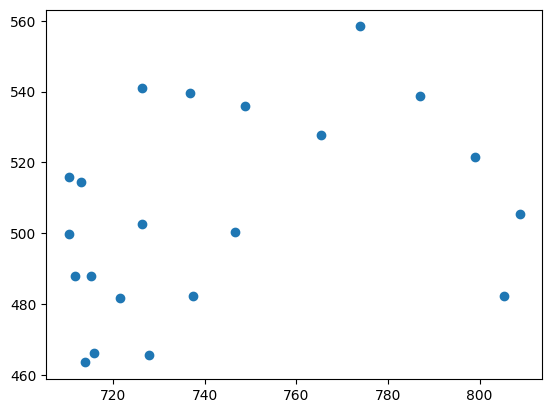

In [63]:
ind = 2
plt.scatter(x[ind], y[ind])

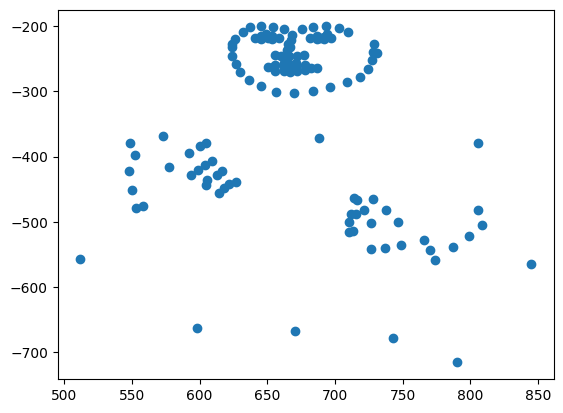

In [77]:
fig, ax = plt.subplots
plt.scatter(x[x != 0], -y[y != 0])

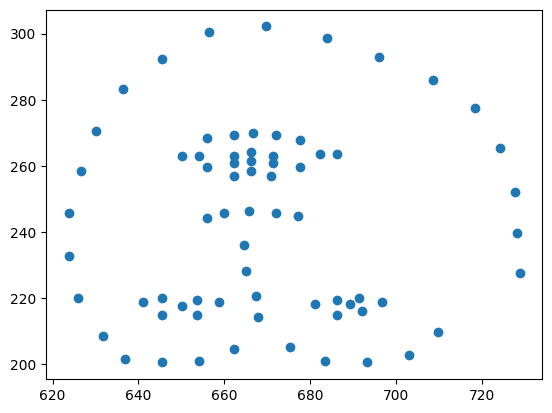

In [64]:
x = data['people'][0]['face_keypoints_2d'][::3]
y = data['people'][0]['face_keypoints_2d'][1:][::3]
plt.scatter(x, y)